In [2]:
from keras import datasets, utils
from keras import models
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

In [7]:
x_train[0,23]

array([  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
        11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0], dtype=uint8)

In [3]:
x_train.shape

(60000, 28, 28)

In [4]:
y_train.shape

(60000,)

In [5]:
def reshape_x(x):
  x = x.reshape((x.shape[0], 28, 28, 1))
  return x

In [6]:
y_train = utils.to_categorical(y_train)
y_test = utils.to_categorical(y_test)

In [7]:
def norm_x(x):
  x_norm = x.astype('float32')
  x_norm /= 255

  return x_norm

In [8]:
model = models.Sequential()
model.add(layers.InputLayer(shape=(28,28,1)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPool2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [9]:
def fit_model(x_train, y_train):
  model.fit(x_train[:1000], y_train[:1000], epochs=10, batch_size=32, verbose=1)
  return model

In [10]:
trainX, testX = reshape_x(x_train), reshape_x(x_test)
trainX = norm_x(trainX)
testX = norm_x(testX)

model = fit_model(trainX[:1000], y_train[:1000])

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4877 - loss: 1.6964
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8674 - loss: 0.4621
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9231 - loss: 0.2838
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9347 - loss: 0.2217
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9665 - loss: 0.1484
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9668 - loss: 0.1204
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9877 - loss: 0.0805
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9819 - loss: 0.0706
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9840 - loss: 0.0643
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9994 - loss: 0.0294


In [11]:
_, acc = model.evaluate(testX[:100], y_test[:100], verbose=0)
print('> %.3f' % (acc * 100.0))

> 95.000


In [20]:
sample = 35

In [21]:
predX = testX[sample].reshape(1, 28, 28, 1)
y_pred = model.predict(predX)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


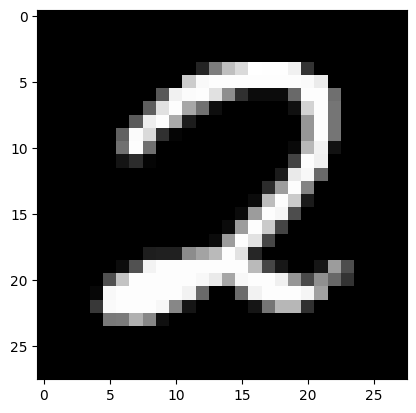

Prediction : 2


In [22]:
img = x_test[sample]
fig = plt.figure
plt.imshow(img, cmap='gray')
plt.show()

max_num = -1
for i, num in enumerate(y_pred[0]):
  if num > max_num:
    max_num = num
    pred_num = i

print(f"Prediction : {pred_num}")